['S5', 'S6']
[12, 14]
[['R0', 'S0', 'S6'], ['R0', 'S1', 'S6'], ['R0', 'S2', 'S6'], ['R0', 'S3', 'S6'], ['R0', 'S4', 'S6']]
5
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'R0+S3s -> R0+S3', 'R0+S4s -> R0+S4', 'S0+S5s -> S0+S5', 'S0+S6s -> S0+S6', 'S1+S5s -> S1+S5', 'S1+S6s -> S1+S6', 'S2+S5s -> S2+S5', 'S2+S6s -> S2+S6', 'S3+S5s -> S3+S5', 'S3+S6s -> S3+S6', 'S4+S5s -> S4+S5', 'S4+S6s -> S4+S6', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'S4s -> S4', 'S5s -> S5', 'S6s -> S6']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]]
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'R0+S3s -> R0+S3', 'R0+S4s -> R0+S4', 'S0+S5s -> S0+S5'

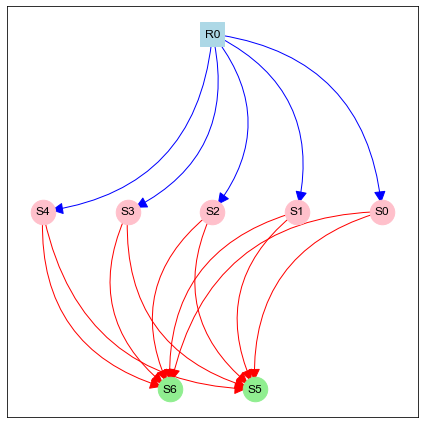

In [8]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time

# --- Example usage with new class structure ---
seed = 52
np.random.seed(seed)
random.seed(seed)

NR = 1

NS_vec = [5,2]
NS = sum(NS_vec)
p_f = 0.75
p_r = 0
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS-2}', f'S{NS-1}']
print(target_nodes)

# species_names, reaction_strings, L, input_indices = generate_random_signaling_network(NR, NL, NL_in, prob, include_reverse=True, include_uncatalyzed=True)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

target_node_idxs = [species_names.index(node) for node in target_nodes]
print(target_node_idxs)
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(n_paths)
print(len(n_paths))
#print(input_indices)
print(reaction_strings)

# n_nodes = 3
# NS = 1
# prob = 1
# extra_reactions = ['A+B -> C+C']
# input_reactions_list = [['R0+A -> R0+B']]
# species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
# #visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)

print(L)
print(reaction_strings)

# NR = 1
# NL_vec = [2,2]
# species_names, reaction_strings, L = generate_feedforward_signaling_network(NR, NL_vec)

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", r_n.n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - r_n.n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()


cycles = compute_cycles(r_n)

# # Visualize linkage classes
# sz = 3
# fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

# if len(r_n.linkage_groups) == 1:
#     pos = nx.spring_layout(r_n.linkage_groups[0])
#     nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#     axes.set_title("Linkage class 1")
# else:
#     for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
#         pos = nx.spring_layout(G)
#         nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#         ax.set_title(f"Linkage class {i+1}")
# plt.tight_layout()
# plt.show()

# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)



rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


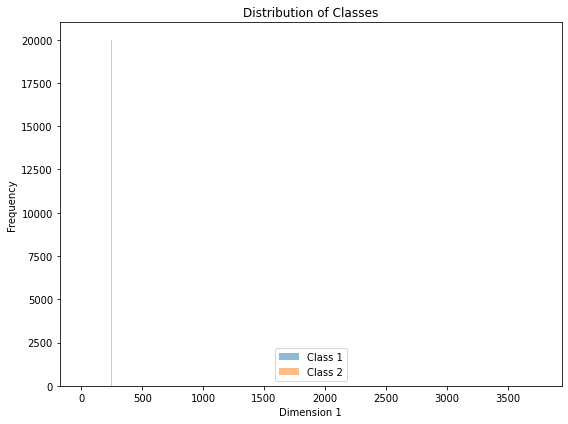

In [24]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

data_type = "gaussians"
n_samples = 20000

if data_type == "gaussian":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1 = scale*7.5e0 * np.ones(input_dim)
    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1 = np.abs(np.random.multivariate_normal(mu_1, cov_1, n_samples))

    mu_2 = scale*1e0 * np.ones(input_dim)
    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "gaussians":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1a = scale*2.5e0 * np.ones(input_dim)
    mu_1b = scale*7.5e2 * np.ones(input_dim)

    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1a = np.abs(np.random.multivariate_normal(mu_1a, cov_1, int(n_samples)))
    dist_1b = np.abs(np.random.multivariate_normal(mu_1b, cov_1, int(n_samples)))
    dist_1 = np.concatenate([dist_1a, dist_1b], axis=0)

    mu_2 = scale*5e1 * np.ones(input_dim)

    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "moons":
    # Convert sklearn noisy_moons to same format as data_list,
    # allowing user to specify scale and offset
    noisy_moons_X, noisy_moons_y = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)

    # Specify the desired scale and offset here
    noisy_moons_scale = 10.0    # Change to your desired scale
    noisy_moons_offset = noisy_moons_scale * np.array([2.0, 2.0])  # Change for desired offset; must have shape (2,)

    # Apply scale and offset
    noisy_moons_X = noisy_moons_X * noisy_moons_scale + noisy_moons_offset
    data_list = [[dat for dat in noisy_moons_X[noisy_moons_y == i]] for i in range(2)]

elif data_type == "circle_vs_square":
    # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
    # Class 0: Points inside circle centered at (x_c, x_c) with radius r
    # Class 1: Points outside the circle
    scale = 1
    offset = scale * 0.0
    x_c = scale * 5.0 + offset     # center coordinate
    r = scale * 3.0         # radius of circle
    
    dist_circle = []  # class 0: inside circle
    dist_square = []  # class 1: outside circle
    
    for _ in range(n_samples):
        # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset
        
        # Check if point is inside circle
        dist_from_center = np.sqrt((x - x_c)**2 + (y - x_c)**2)
        
        if dist_from_center <= r:
            dist_circle.append(np.array([x, y]))
        else:
            dist_square.append(np.array([x, y]))
    
    data_list = [dist_circle, dist_square]

elif data_type == "diagonal_cut":
    # Classify according to which side of the diagonal y = x the point is on
    # Class 0: y > x; Class 1: y <= x
    scale = 0.2
    offset = scale * 2.0
    x_c = scale * 5.0 + offset  # to keep square region similar to above
    dist_above = []   # class 0: y > x
    dist_below = []   # class 1: y <= x

    for _ in range(n_samples):
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset

        if y > x:
            dist_above.append(np.array([x, y]))
        else:
            dist_below.append(np.array([x, y]))
    
    data_list = [dist_above, dist_below]

elif data_type == "bottom_quarter_intersect":
    # Class 0: Points in the bottom quarter region defined by the intersection of y = x and y = 1 - x
    # inside the square [0, 1] x [0, 1], then apply scale and offset
    # Class 1: All other points inside the [0, 1] x [0, 1] square, excluding class 0.
    # That region is the triangle below both lines: y <= x AND y <= 1 - x. This triangle's vertices are: (0,0), (0.5,0), (1,0)
    dist_bottom_quarter = []  # class 0
    dist_other = []           # class 1
    
    scale = 10
    offset = scale * 0.0

    for _ in range(n_samples):
        # generate point in [0,1]x[0,1]
        x = np.random.uniform(0, 1)
        y = np.random.uniform(0, 1)

        # Triangle: y <= x AND y <= 1-x
        if y <= x and y <= 1 - x:
            # Apply scale and offset before adding
            p = np.array([x, y]) * scale + offset
            dist_bottom_quarter.append(p)
        else:
            p = np.array([x, y]) * scale + offset
            dist_other.append(p)

    data_list = [dist_bottom_quarter, dist_other]


input_data = InputData(n_classes, data_list)

# Redefine dist_1 and dist_2 from data_list for legacy code compatibility, but now as np.arrays
dist_1 = np.vstack(data_list[0])
dist_2 = np.vstack(data_list[1])

plt.figure(figsize=(8, 6))
if dist_1.shape[1] == 1:
    # Use fixed-width bins based on the min/max over both classes
    all_x = np.concatenate([dist_1[:, 0], dist_2[:, 0]])
    bin_width = 5  # Set desired bin width here
    bins = np.arange(np.min(all_x), np.max(all_x) + bin_width, bin_width)
    plt.hist(dist_1[:, 0], bins=bins, alpha=0.5, label='Class 1')
    plt.hist(dist_2[:, 0], bins=bins, alpha=0.5, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Frequency')
elif dist_1.shape[1] == 2:
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
else:
    # More than 2 dimensions: project to first two
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
plt.title('Distribution of Classes')
plt.legend()
plt.tight_layout()
plt.show()



Starting training: 250 batches, batch_size=20
Batch    0/250 | Loss: 0.8396 (avg: 0.8396) | Acc: 55.0% (avg: 55.0%) | GradNorm: 8.13e-01 | T: 0.50
Batch   50/250 | Loss: 0.8025 (avg: 0.8196) | Acc: 55.0% (avg: 52.3%) | GradNorm: 1.71e+00 | T: 0.50
Batch  100/250 | Loss: 0.0134 (avg: 0.6032) | Acc: 100.0% (avg: 67.5%) | GradNorm: 1.29e-01 | T: 0.50
Batch  150/250 | Loss: 0.0024 (avg: 0.1977) | Acc: 100.0% (avg: 91.3%) | GradNorm: 4.33e-03 | T: 0.50
Batch  200/250 | Loss: 0.0006 (avg: 0.0644) | Acc: 100.0% (avg: 98.5%) | GradNorm: 8.53e-06 | T: 0.50
Batch  249/250 | Loss: 0.0000 (avg: 0.1472) | Acc: 100.0% (avg: 97.3%) | GradNorm: 1.81e-03 | T: 0.50

Training Summary
Training time: 0.7 seconds
Final loss (last 100 batches): 0.1472
Min loss achieved: 0.0000
Final accuracy (last 100 batches): 97.3%
Best accuracy: 100.0%
Final param range: [-7.22e+00, 8.63e+00], mean: -3.53e-02


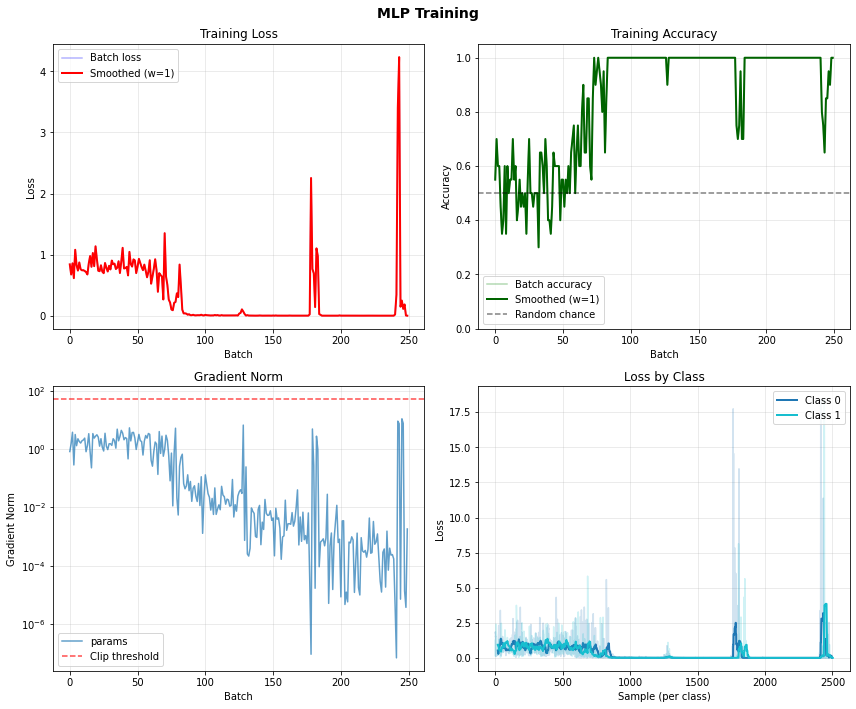

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [52]:
from CRNs.training import (SimpleMLP, MLPModel, UnifiedTrainer, 
                           TrainingHistory, run_training, plot_training_diagnostics)

# Setup
mlp = SimpleMLP([NR, 6, n_classes], activation='tanh')
model = MLPModel(mlp, n_classes=n_classes)
trainer = UnifiedTrainer(model, lr=0.1, max_grad_norm=50.0)

# Run training in one line!
history = run_training(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=250,
    batch_size=20,
    T_start=0.5, T_end=0.5, T_decay=0.99,
    noise_start=0.0, noise_end=0.0, noise_decay=0.9,
    print_every=50
)

# Plot results
plot_training_diagnostics(history, title="MLP Training", max_grad_norm=50.0, smoothing_window=1)

[1. 1. 1. 1. 1. 1. 1. 1.]
Starting CRN (graph) training: 500 batches, batch_size=20
Batch    0/500 | Loss: 0.7215 (avg: 0.7215) | Acc: 25.0% (avg: 25.0%) | log_ra:1.19e-01 log_l0:4.51e-01 | Rates: [2.93e-02, 1.37e+02]
Batch   50/500 | Loss: 0.5078 (avg: 0.6672) | Acc: 80.0% (avg: 61.2%) | log_ra:1.88e-01 log_l0:4.11e-01 | Rates: [1.77e-03, 1.40e+04]
Batch  100/500 | Loss: 0.0000 (avg: 0.3483) | Acc: 100.0% (avg: 80.5%) | log_ra:9.00e-05 log_l0:1.85e-04 | Rates: [1.36e-04, 5.63e+04]
Batch  150/500 | Loss: -0.0000 (avg: 0.0153) | Acc: 100.0% (avg: 99.5%) | log_ra:1.39e-07 log_l0:2.42e-07 | Rates: [1.36e-04, 5.63e+04]
Batch  200/500 | Loss: -0.0000 (avg: 0.0000) | Acc: 100.0% (avg: 100.0%) | log_ra:6.54e-10 log_l0:5.90e-10 | Rates: [1.36e-04, 5.63e+04]
Batch  250/500 | Loss: -0.0000 (avg: -0.0000) | Acc: 100.0% (avg: 100.0%) | log_ra:1.01e-08 log_l0:2.06e-08 | Rates: [1.36e-04, 5.63e+04]
Batch  300/500 | Loss: -0.0000 (avg: -0.0000) | Acc: 100.0% (avg: 100.0%) | log_ra:1.00e-08 log_l0:2.0

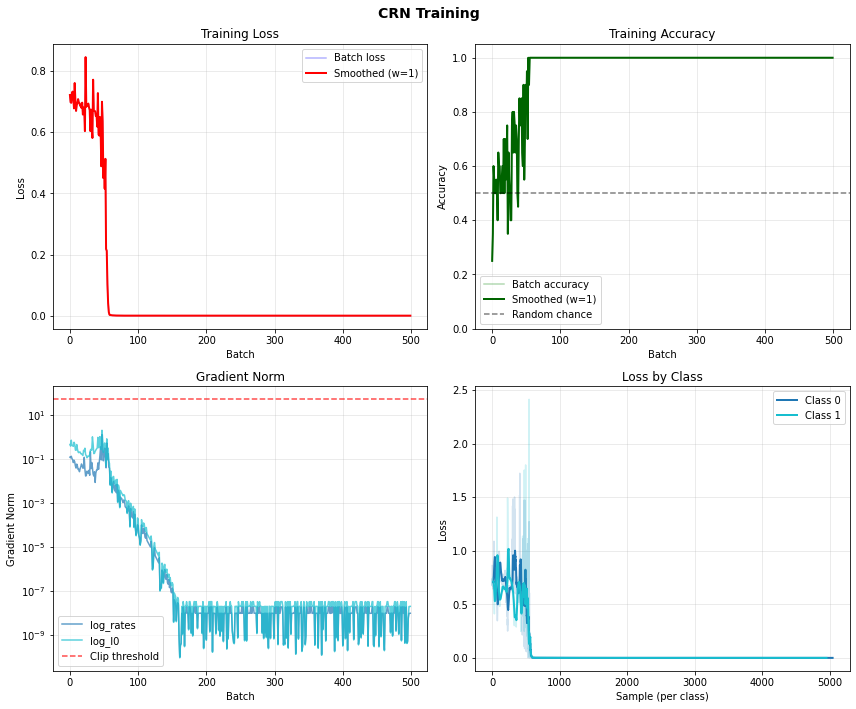

In [27]:
from CRNs.training import CRNModel, UnifiedTrainer, run_training_crn


# ============== INITIALIZATION ==============
E_range = 0.0
B_range = 0.0
F_range = 0.0
C0 = 1
beta = 1

#rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)

n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 2)  # Log-normal, wider spread
r_n.update_rates(rates)

log_rates = np.log(rates)
r_n.update_rates(rates)
n_rates = len(rates)
default_l0 = np.ones(NR + NS)
num_intermediate_nodes = NS - len(target_nodes)
#default_l0[NR: NR + num_intermediate_nodes] = 50 * np.abs(np.random.randn(num_intermediate_nodes))
print(default_l0)

graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)


# Setup CRN model
crn_model = CRNModel(
    r_n=r_n, sim=sim, L=L,
    class_ids=target_node_idxs,
    n_inputs=NR,
    default_l0=default_l0,
    forward_method='graph',  # or 'graph'
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

trainer = UnifiedTrainer(
    crn_model, 
    lr_dict={'log_rates': 0.1, 'log_l0': 0.1},
    max_grad_norm=50.0
)

# Run CRN training
history = run_training_crn(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=500,
    batch_size=20,
    T_start=1.0, T_end=0.2, T_decay=0.99,
    noise_start=1.0, noise_end=0.0, noise_decay=0.99,
    print_every=50
)


plot_training_diagnostics(history, title="CRN Training", max_grad_norm=50.0, smoothing_window=1);



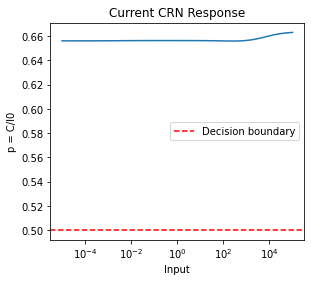

In [20]:
import matplotlib.pyplot as plt

# Sweep input and plot output
input_range = np.logspace(-5, 5, 100)
outputs = []

for inp in input_range:
    p = binary_model.forward(np.array([inp]))[0]
    outputs.append(p)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(input_range, outputs)
plt.xscale('log')
plt.axhline(0.5, color='r', linestyle='--', label='Decision boundary')
plt.xlabel('Input')
plt.ylabel('p = C/l0')
plt.title('Current CRN Response')
plt.legend()

# # Also show where your training data lies
# plt.subplot(1, 2, 2)
# for c in [0, 1]:
#     samples = [input_data.get_next_training_sample(c)[0] for _ in range(50)]
#     plt.hist(samples, alpha=0.5, label=f'Class {c}', bins=20)
# plt.xlabel('Input')
# plt.title('Training Data Distribution')
# plt.legend()
# plt.show()